# 3MD3220 Reinforcement Learning — Individual Assignment

**Author:** Hamza TBATOU

This notebook presents an experimental comparison between **constant-\(\alpha\) first-visit Monte Carlo control** and **Sarsa(\(\lambda\)) with replacing eligibility traces** on **Text Flappy Bird**.  
The core experiments are conducted on the compact-state environment `TextFlappyBird-v0`, which is suitable for a **tabular reinforcement learning** approach.  
The screen-based variant, `TextFlappyBird-screen-v0`, is also briefly examined to highlight why it is much less appropriate for tabular methods.

---

## Notebook Roadmap

This notebook is organized as follows:

1. **Environment setup**  
   Check and install the required packages if needed.

2. **Reproducibility and utilities**  
   Define random seeds, helper functions, and shared experiment utilities.

3. **Agent implementation**  
   Implement the two tabular RL agents:
   - constant-$\alpha$ first-visit Monte Carlo control
   - Sarsa($\lambda$) with replacing eligibility traces

4. **Main experimental comparison**  
   Train and compare both agents on the base configuration of `TextFlappyBird-v0`.

5. **Extended analysis**  
   Study:
   - parameter sensitivity
   - learned value functions and greedy policies
   - transfer and generalization to different level configurations

6. **Report material**  
   Reuse the generated figures together with the companion report material for the final LNCS submission.

---

## Main Experimental Choices

The main setup used throughout the notebook is:

- **Base environment:** `TextFlappyBird-v0`
- **Base level configuration:** `height=15`, `width=20`, `pipe_gap=4`
- **Comparison environment:** `TextFlappyBird-screen-v0`
- **Training seeds:** `7`, `21`, `84`, `168`
- **Evaluation protocol:** greedy rollouts after training, with $\epsilon = 0$

---

## Important Reading Note

The **training curves** are obtained under **epsilon-greedy exploration**, while the **evaluation tables, boxplots, and final scores** are computed using the **greedy policy** learned after training.  
Because of this, evaluation performance can be significantly higher than the smoothed training performance.

---

## What This Notebook Delivers

This notebook provides:

- a **reproducible experimental setup**
- a **direct comparison** of the two requested agents on the base environment
- **parameter sweeps** for both algorithms
- **state/action-value visualizations** and greedy policy maps
- a **generalization study** across different level configurations
- written interpretations of the results that can be reused in the final short report

## 1. Setup And Reproducibility

The first cells verify the software stack, define the reproducible run configuration, and set the base Text Flappy Bird parameters used in the rest of the notebook.

In [1]:
import importlib.util
import subprocess
import sys

PACKAGE_SPECS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "gymnasium": "gymnasium",
    "text_flappy_bird_gym": "https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym/-/archive/master/text-flappy-bird-gym-master.zip",
}

missing_packages = [spec for module_name, spec in PACKAGE_SPECS.items() if importlib.util.find_spec(module_name) is None]

if missing_packages:
    print("Installing missing packages:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required packages are already available.")


All required packages are already available.


In [ ]:
from __future__ import annotations

# Standard library imports
import itertools
import random
import warnings
from dataclasses import dataclass
from typing import Any, Callable

# Visualization and data analysis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.colors import BoundaryNorm, ListedColormap

# RL environment
import gymnasium as gym
import text_flappy_bird_gym

# Silence non-critical warnings to keep notebook output clean
warnings.filterwarnings("ignore")

# Global plotting style for all figures in the notebook
sns.set_theme(style="whitegrid", context="talk")

# Display pandas floats with 3 decimals for readability
pd.options.display.float_format = "{:.3f}".format

# ---------------------------------------------------------------------
# Experiment profile
# "fast"  -> quick debug / test runs
# "final" -> full experiments used for the report and submission figures
# ---------------------------------------------------------------------
RUN_PROFILE = "final" # Change to "fast" for quicker runs during development

# Preset configurations for the two run modes
PROFILE_PRESETS = {
    "fast": {
        "seeds": [7, 21],                  # fewer seeds for quicker runs
        "train_episodes": 1500,            # shorter training
        "sweep_episodes": 600,             # shorter parameter sweeps
        "eval_episodes": 30,               # fewer evaluation episodes
        "transfer_eval_episodes": 25,      # fewer transfer/generalization episodes
        "max_steps": 5000,                 # safety cap per episode
        "rolling_window": 75,              # smoothing window for training curves
    },
    "final": {
        "seeds": [7, 21, 84, 168],         # seeds used for final reported results
        "train_episodes": 6000,            # full training budget
        "sweep_episodes": 2000,            # more reliable parameter sweeps
        "eval_episodes": 100,              # stronger evaluation estimate
        "transfer_eval_episodes": 75,      # more stable transfer results
        "max_steps": 5000,                 # safety cap per episode
        "rolling_window": 200,             # smoother plots for final figures
    },
}

# Load the selected preset into one shared settings dictionary
SETTINGS = PROFILE_PRESETS[RUN_PROFILE]

# ---------------------------------------------------------------------
# Global constants used throughout the notebook
# ---------------------------------------------------------------------
GLOBAL_SEED = 2026
DEFAULT_ENV_ID = "TextFlappyBird-v0"
SCREEN_ENV_ID = "TextFlappyBird-screen-v0"

# Base level configuration used in the main comparison
BASE_ENV_CONFIG = {"height": 15, "width": 20, "pipe_gap": 4}

# Human-readable labels for actions
ACTION_LABELS = {0: "idle", 1: "flap"}

# Set global random seeds for reproducibility
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# Print a quick summary of the active experimental setup
print("Run profile:", RUN_PROFILE)
print("Settings:", SETTINGS)
print("Base environment:", BASE_ENV_CONFIG)

Run profile: final
Settings: {'seeds': [7, 21, 84, 168], 'train_episodes': 6000, 'sweep_episodes': 2000, 'eval_episodes': 100, 'transfer_eval_episodes': 75, 'max_steps': 5000, 'rolling_window': 200}
Base environment: {'height': 15, 'width': 20, 'pipe_gap': 4}


## 2. Environment Abstraction And Agent Definitions

The helper code below standardizes the environment API, discretizes the compact observation space, and defines the two tabular agents required in the assignment. Using the compact `TextFlappyBird-v0` observation makes the problem tractable for tabular RL, while the screen-based variant is kept for discussion and comparison.

In [ ]:
def make_tfb(env_id: str = DEFAULT_ENV_ID, **env_kwargs: Any):
    # Create a Text Flappy Bird environment instance with the given configuration.
    return gym.make(env_id, **env_kwargs)


def build_env_factory(env_id: str = DEFAULT_ENV_ID, **env_kwargs: Any) -> Callable[[], Any]:
    # Store the configuration once so the factory can recreate identical environments later.
    config = dict(env_kwargs)

    def _factory():
        # Build a fresh environment each time the factory is called.
        return make_tfb(env_id=env_id, **config)

    return _factory


def reset_env(env: Any, seed: int | None = None):
    # Handle both Gymnasium-style reset(seed=...) and older reset() APIs.
    try:
        outcome = env.reset(seed=seed)
    except TypeError:
        outcome = env.reset()

    # Gymnasium usually returns (observation, info); keep that format if available.
    if isinstance(outcome, tuple) and len(outcome) == 2 and isinstance(outcome[1], dict):
        return outcome

    # Otherwise, emulate the Gymnasium format by adding an empty info dict.
    return outcome, {}


def step_env(env: Any, action: int):
    # Force the action to be an integer before stepping the environment.
    outcome = env.step(int(action))

    # Gymnasium API: (obs, reward, terminated, truncated, info)
    if isinstance(outcome, tuple) and len(outcome) == 5:
        next_obs, reward, terminated, truncated, info = outcome
        done = bool(terminated or truncated)
        return next_obs, float(reward), done, info

    # Older Gym API: (obs, reward, done, info)
    next_obs, reward, done, info = outcome
    return next_obs, float(reward), bool(done), info


def preview_observation(obs: Any, max_rows: int = 6, max_cols: int = 10) -> str:
    # Convert different observation formats into a compact printable summary.
    if isinstance(obs, np.ndarray):
        arr = obs
    elif isinstance(obs, (list, tuple)):
        try:
            arr = np.asarray(obs)
        except Exception:
            return repr(obs)
    else:
        return repr(obs)

    # Scalar observation: print the scalar value.
    if arr.ndim == 0:
        return repr(arr.item())

    # 1D observation: print the list representation.
    if arr.ndim == 1:
        return repr(arr.tolist())

    # Small 2D observation: print a clipped array directly.
    if arr.ndim == 2 and arr.size <= max_rows * max_cols * 2:
        clipped = arr[:max_rows, :max_cols]
        return np.array2string(clipped, threshold=max_rows * max_cols)

    # Larger arrays: return only a summary to avoid huge notebook outputs.
    summary = {"shape": tuple(arr.shape), "dtype": str(arr.dtype)}
    if np.issubdtype(arr.dtype, np.number):
        summary.update({"min": float(np.min(arr)), "max": float(np.max(arr))})
    return repr(summary)


# Create one temporary environment to infer the action space size automatically.
tmp_env = build_env_factory(**BASE_ENV_CONFIG)()
N_ACTIONS = int(tmp_env.action_space.n)
tmp_env.close()
print("Detected number of actions:", N_ACTIONS)


@dataclass(frozen=True)
class Discretizer:
    # Bounds used to clip the horizontal and vertical coordinates.
    x_clip: tuple[int, int]
    y_clip: tuple[int, int]
    # Optional scaling factors before rounding/clipping.
    x_scale: float = 1.0
    y_scale: float = 1.0

    def __call__(self, obs: Any) -> tuple[int, int]:
        # Convert the observation to a flat numeric array.
        arr = np.asarray(obs, dtype=float).reshape(-1)
        # This project expects at least two coordinates: horizontal and vertical.
        if arr.size < 2:
            raise ValueError(f"Expected a 2D observation, received {obs!r}")
        # Scale, round, and clip each coordinate to obtain a tabular state.
        x = int(np.clip(np.rint(arr[0] / self.x_scale), *self.x_clip))
        y = int(np.clip(np.rint(arr[1] / self.y_scale), *self.y_clip))
        return x, y


def make_discretizer(height: int, width: int, pipe_gap: int, x_scale: float = 1.0, y_scale: float = 1.0) -> Discretizer:
    # pipe_gap is kept in the signature for consistency with environment configs,
    # even if it is not directly used in this discretization rule.
    _ = pipe_gap
    return Discretizer(x_clip=(-width, width), y_clip=(-height, height), x_scale=x_scale, y_scale=y_scale)


def ensure_state(q_table: dict[tuple[int, int], np.ndarray], state: tuple[int, int], n_actions: int) -> np.ndarray:
    # Initialize unseen states lazily with zero action-values.
    if state not in q_table:
        q_table[state] = np.zeros(n_actions, dtype=float)
    return q_table[state]


def read_state(q_table: dict[tuple[int, int], np.ndarray], state: tuple[int, int], n_actions: int) -> np.ndarray:
    # Read the action-values for a state without modifying the Q-table.
    # Unseen states are treated as zero-valued.
    return q_table.get(state, np.zeros(n_actions, dtype=float))


def greedy_action(q_values: np.ndarray, rng: np.random.Generator) -> int:
    # Compute the maximal Q-value.
    best_value = np.max(q_values)
    # Keep all maximizing actions to break ties randomly.
    best_actions = np.flatnonzero(np.isclose(q_values, best_value))
    return int(rng.choice(best_actions))


def epsilon_greedy_action(q_values: np.ndarray, epsilon: float, rng: np.random.Generator) -> int:
    # Explore with probability epsilon.
    if rng.random() < epsilon:
        return int(rng.integers(len(q_values)))
    # Otherwise exploit the greedy action.
    return greedy_action(q_values, rng)


def infer_score(info: dict[str, Any], rewards: list[float]) -> float:
    # Try to recover an environment-provided score first.
    if isinstance(info, dict):
        for key in ("score", "points", "pipes_passed"):
            if key in info:
                try:
                    return float(info[key])
                except (TypeError, ValueError):
                    pass
    # Fallback heuristic: count positive rewards as passed pipes / points.
    return float(sum(reward > 0 for reward in rewards))


def evaluate_policy(env_factory: Callable[[], Any], q_table: dict[tuple[int, int], np.ndarray], episodes: int, discretizer: Discretizer, seed: int = 0, epsilon: float = 0.0, max_steps: int = 5000) -> pd.DataFrame:
    # Use a dedicated RNG so evaluation is reproducible and isolated from training.
    rng = np.random.default_rng(seed)
    env = env_factory()
    rows = []

    # Run several evaluation episodes and record summary metrics.
    for episode in range(episodes):
        obs, _ = reset_env(env, seed=seed + episode)
        state = discretizer(obs)
        rewards: list[float] = []
        info: dict[str, Any] = {}

        for _ in range(max_steps):
            # Select actions from the learned Q-table, usually greedily during evaluation.
            action = epsilon_greedy_action(read_state(q_table, state, N_ACTIONS), epsilon, rng)
            next_obs, reward, done, info = step_env(env, action)
            rewards.append(reward)
            if done:
                break
            state = discretizer(next_obs)

        # Store return, inferred score, and episode length for later analysis.
        rows.append({"episode": episode + 1, "return": float(np.sum(rewards)), "score": infer_score(info, rewards), "length": len(rewards)})

    env.close()
    return pd.DataFrame(rows)

Detected number of actions: 2


In [ ]:
def train_monte_carlo_control(env_factory: Callable[[], Any], episodes: int, gamma: float, epsilon: float, alpha: float, discretizer: Discretizer, max_steps: int, seed: int) -> tuple[dict[tuple[int, int], np.ndarray], pd.DataFrame]:
    # Create a reproducible RNG for action selection.
    rng = np.random.default_rng(seed)
    # Q-table maps each discretized state to a vector of action-values.
    q_table: dict[tuple[int, int], np.ndarray] = {}
    env = env_factory()
    # This will store per-episode training statistics.
    history_rows = []

    for episode in range(episodes):
        # Reset the environment with a deterministic episode-specific seed.
        obs, _ = reset_env(env, seed=seed + episode)
        state = discretizer(obs)
        # Store the full episode so returns can be computed backward at the end.
        trajectory: list[tuple[tuple[int, int], int, float]] = []
        rewards: list[float] = []
        info: dict[str, Any] = {}

        for _ in range(max_steps):
            # Epsilon-greedy behavior policy.
            action = epsilon_greedy_action(ensure_state(q_table, state, N_ACTIONS), epsilon, rng)
            next_obs, reward, done, info = step_env(env, action)
            # Save (state, action, reward) for the Monte Carlo return computation.
            trajectory.append((state, action, reward))
            rewards.append(reward)
            if done:
                break
            # Move to the next discretized state.
            state = discretizer(next_obs)

        # Keep track of already updated state-action pairs to implement first-visit MC.
        seen_pairs: set[tuple[tuple[int, int], int]] = set()
        G = 0.0
        # Traverse the trajectory backward to accumulate discounted returns.
        for state_t, action_t, reward_t in reversed(trajectory):
            G = gamma * G + reward_t
            key = (state_t, action_t)
            # Skip repeated occurrences so only the first visit is updated.
            if key in seen_pairs:
                continue
            seen_pairs.add(key)
            # Constant-alpha update toward the observed return G.
            ensure_state(q_table, state_t, N_ACTIONS)[action_t] += alpha * (G - ensure_state(q_table, state_t, N_ACTIONS)[action_t])

        # Log training metrics for later analysis and plotting.
        history_rows.append({"episode": episode + 1, "return": float(np.sum(rewards)), "score": infer_score(info, rewards), "length": len(rewards), "visited_states": len(q_table)})

    env.close()
    return q_table, pd.DataFrame(history_rows)


def train_sarsa_lambda(env_factory: Callable[[], Any], episodes: int, gamma: float, epsilon: float, alpha: float, lam: float, discretizer: Discretizer, max_steps: int, seed: int, trace_type: str = "replacing") -> tuple[dict[tuple[int, int], np.ndarray], pd.DataFrame]:
    # Create a reproducible RNG for epsilon-greedy action selection.
    rng = np.random.default_rng(seed)
    # Q-table maps each discretized state to a vector of action-values.
    q_table: dict[tuple[int, int], np.ndarray] = {}
    env = env_factory()
    # This will store per-episode training statistics.
    history_rows = []

    for episode in range(episodes):
        # Eligibility traces are reset at the beginning of each episode.
        traces: dict[tuple[int, int], np.ndarray] = {}
        obs, _ = reset_env(env, seed=seed + episode)
        state = discretizer(obs)
        # Choose the initial action using the current epsilon-greedy policy.
        action = epsilon_greedy_action(ensure_state(q_table, state, N_ACTIONS), epsilon, rng)
        rewards: list[float] = []
        info: dict[str, Any] = {}

        for _ in range(max_steps):
            next_obs, reward, done, info = step_env(env, action)
            rewards.append(reward)

            # If the episode ends, the TD target is just the terminal reward.
            if done:
                target = reward
            else:
                # Otherwise bootstrap with the next state-action value.
                next_state = discretizer(next_obs)
                next_action = epsilon_greedy_action(ensure_state(q_table, next_state, N_ACTIONS), epsilon, rng)
                target = reward + gamma * ensure_state(q_table, next_state, N_ACTIONS)[next_action]

            # TD error for the current transition.
            delta = target - ensure_state(q_table, state, N_ACTIONS)[action]
            # Lazily initialize the trace vector for unseen states.
            if state not in traces:
                traces[state] = np.zeros(N_ACTIONS, dtype=float)

            # Replacing traces set the current trace to 1; accumulating traces add 1.
            if trace_type == "replacing":
                traces[state][action] = 1.0
            else:
                traces[state][action] += 1.0

            # Update all traced state-action values and decay their traces.
            for traced_state in list(traces):
                ensure_state(q_table, traced_state, N_ACTIONS)[:] += alpha * delta * traces[traced_state]
                traces[traced_state] *= gamma * lam
                # Drop negligible traces to keep the dictionary compact.
                if np.max(np.abs(traces[traced_state])) < 1e-8:
                    del traces[traced_state]

            if done:
                break

            # Move to the next on-policy state-action pair.
            state, action = next_state, next_action

        # Log training metrics for later comparison and plotting.
        history_rows.append({"episode": episode + 1, "return": float(np.sum(rewards)), "score": infer_score(info, rewards), "length": len(rewards), "visited_states": len(q_table)})

    env.close()
    return q_table, pd.DataFrame(history_rows)

In [ ]:
def plot_learning_curves(history_df: pd.DataFrame, rolling_window: int) -> None:
    # Create one panel for returns and one panel for scores.
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
    for ax, metric in zip(axes, ["return", "score"]):
        # Plot each agent separately.
        for agent_name, subset in history_df.groupby("agent"):
            # First draw light per-seed smoothed curves to show variability.
            for _, seed_history in subset.groupby("seed"):
                smoothed = seed_history[metric].rolling(rolling_window, min_periods=1).mean()
                ax.plot(seed_history["episode"], smoothed, alpha=0.20, linewidth=1)
            # Then draw the thicker average curve across seeds.
            mean_curve = subset.groupby("episode")[metric].mean().rolling(rolling_window, min_periods=1).mean()
            ax.plot(mean_curve.index, mean_curve.values, linewidth=3, label=agent_name)
        ax.set_title(f"Training {metric.title()} (rolling mean)")
        ax.set_xlabel("Episode")
        ax.set_ylabel(metric.title())
        ax.legend()
    plt.tight_layout()
    plt.show()


def plot_evaluation_distributions(evaluation_df: pd.DataFrame) -> None:
    # Compare final evaluation performance distributions across agents.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(data=evaluation_df, x="agent", y="return", ax=axes[0])
    sns.boxplot(data=evaluation_df, x="agent", y="score", ax=axes[1])
    axes[0].set_title("Evaluation Returns")
    axes[1].set_title("Evaluation Scores")
    axes[0].set_xlabel("")
    axes[1].set_xlabel("")
    plt.tight_layout()
    plt.show()


def plot_value_heatmap(q_table: dict[tuple[int, int], np.ndarray], title: str, ax: Any | None = None) -> None:
    # Plot max_a Q(s, a) over the discretized state space.
    ax = ax or plt.gca()
    if not q_table:
        ax.set_title(f"{title} (empty)")
        return
    # Extract all visited x and y coordinates.
    x_values = sorted({state[0] for state in q_table})
    y_values = sorted({state[1] for state in q_table}, reverse=True)
    # Initialize a grid filled with NaNs for unvisited states.
    grid = np.full((len(y_values), len(x_values)), np.nan)
    x_index = {value: idx for idx, value in enumerate(x_values)}
    y_index = {value: idx for idx, value in enumerate(y_values)}
    # Fill each visited cell with the maximum action-value at that state.
    for state, values in q_table.items():
        grid[y_index[state[1]], x_index[state[0]]] = float(np.max(values))
    heatmap_df = pd.DataFrame(grid, index=y_values, columns=x_values)
    sns.heatmap(heatmap_df, cmap="viridis", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("x distance to next pipe gap center")
    ax.set_ylabel("y offset from gap center")


def plot_policy_heatmap(q_table: dict[tuple[int, int], np.ndarray], title: str, ax: Any | None = None) -> None:
    # Plot the greedy action argmax_a Q(s, a) over the discretized state space.
    ax = ax or plt.gca()
    if not q_table:
        ax.set_title(f"{title} (empty)")
        return
    # Extract all visited x and y coordinates.
    x_values = sorted({state[0] for state in q_table})
    y_values = sorted({state[1] for state in q_table}, reverse=True)
    # Initialize a grid filled with NaNs for unvisited states.
    grid = np.full((len(y_values), len(x_values)), np.nan)
    x_index = {value: idx for idx, value in enumerate(x_values)}
    y_index = {value: idx for idx, value in enumerate(y_values)}
    # Fill each visited cell with the greedy action index.
    for state, values in q_table.items():
        grid[y_index[state[1]], x_index[state[0]]] = float(np.argmax(values))
    # Use a 2-color map: one color for each action.
    cmap = ListedColormap(["#4575b4", "#d73027"])
    norm = BoundaryNorm(boundaries=[-0.5, 0.5, 1.5], ncolors=cmap.N)
    masked = np.ma.masked_invalid(grid)
    image = ax.imshow(masked, cmap=cmap, norm=norm, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("x distance to next pipe gap center")
    ax.set_ylabel("y offset from gap center")
    ax.set_xticks(range(len(x_values)))
    ax.set_xticklabels(x_values, rotation=90)
    ax.set_yticks(range(len(y_values)))
    ax.set_yticklabels(y_values)
    # Add a colorbar to map action ids back to action names.
    cbar = plt.colorbar(image, ax=ax, ticks=[0, 1])
    cbar.ax.set_yticklabels([ACTION_LABELS[0], ACTION_LABELS[1]])


def run_training_suite(agent_name: str, train_fn: Callable[..., tuple[dict[tuple[int, int], np.ndarray], pd.DataFrame]], train_kwargs: dict[str, Any], seeds: list[int], eval_episodes: int) -> dict[str, Any]:
    # Train and evaluate one agent over multiple random seeds.
    histories = []
    evaluations = []
    q_tables: dict[int, dict[tuple[int, int], np.ndarray]] = {}
    for seed in seeds:
        # Train one model for the current seed.
        q_table, history = train_fn(seed=seed, **train_kwargs)
        history = history.assign(seed=seed, agent=agent_name)
        # Evaluate the greedy policy learned from this seed.
        evaluation = evaluate_policy(env_factory=train_kwargs["env_factory"], q_table=q_table, episodes=eval_episodes, discretizer=train_kwargs["discretizer"], seed=10_000 + seed, epsilon=0.0, max_steps=train_kwargs["max_steps"]).assign(seed=seed, agent=agent_name)
        q_tables[seed] = q_table
        histories.append(history)
        evaluations.append(evaluation)
    # Return all raw outputs needed for later plotting and analysis.
    return {"q_tables": q_tables, "history": pd.concat(histories, ignore_index=True), "evaluation": pd.concat(evaluations, ignore_index=True)}


def parameter_sweep(agent_name: str, train_fn: Callable[..., tuple[dict[tuple[int, int], np.ndarray], pd.DataFrame]], fixed_kwargs: dict[str, Any], param_grid: dict[str, list[Any]], seeds: list[int], eval_episodes: int) -> pd.DataFrame:
    # Evaluate several hyperparameter combinations across multiple seeds.
    rows = []
    param_names = list(param_grid)
    for values in itertools.product(*(param_grid[name] for name in param_names)):
        # Build one hyperparameter configuration from the cartesian product.
        chosen_params = dict(zip(param_names, values))
        for seed in seeds:
            current_kwargs = dict(fixed_kwargs)
            current_kwargs.update(chosen_params)
            # Train with the current parameter choice.
            q_table, history = train_fn(seed=seed, **current_kwargs)
            # Evaluate the learned greedy policy.
            evaluation = evaluate_policy(env_factory=current_kwargs["env_factory"], q_table=q_table, episodes=eval_episodes, discretizer=current_kwargs["discretizer"], seed=50_000 + seed, epsilon=0.0, max_steps=current_kwargs["max_steps"])
            # Average the end of training only, to reduce noise from early learning.
            tail_size = min(100, len(history))
            rows.append({"agent": agent_name, "seed": seed, **chosen_params, "final_train_return": history["return"].tail(tail_size).mean(), "final_train_score": history["score"].tail(tail_size).mean(), "eval_mean_return": evaluation["return"].mean(), "eval_mean_score": evaluation["score"].mean(), "visited_states": len(q_table)})
    return pd.DataFrame(rows)


def plot_parameter_sweeps(mc_sweep_df: pd.DataFrame, sarsa_sweep_df: pd.DataFrame) -> None:
    # Show Monte Carlo sensitivity as line plots and Sarsa(lambda) sensitivity as a heatmap.
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    mc_summary = mc_sweep_df.groupby(["epsilon", "alpha"], as_index=False)["eval_mean_score"].mean()
    sns.lineplot(data=mc_summary, x="epsilon", y="eval_mean_score", hue="alpha", marker="o", ax=axes[0])
    axes[0].set_title("Monte Carlo parameter sweep")
    axes[0].set_ylabel("Mean evaluation score")
    sarsa_summary = sarsa_sweep_df.groupby(["alpha", "lam"], as_index=False)["eval_mean_score"].mean()
    heatmap_df = sarsa_summary.pivot(index="alpha", columns="lam", values="eval_mean_score")
    sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="crest", ax=axes[1])
    axes[1].set_title("Sarsa(lambda) parameter sweep")
    axes[1].set_ylabel("alpha")
    axes[1].set_xlabel("lambda")
    plt.tight_layout()
    plt.show()

## 3. Base Experiment: Environment Comparison, Training, And Evaluation

This section inspects both environment variants, trains the two agents on the same base configuration, and compares them with a summary table, learning curves, and greedy evaluation boxplots.

,env_id,action_space,observation_space,sample_observation
0,TextFlappyBird-v0,Discrete(2),"Tuple(Discrete(14), Discrete(22, start=-11))","[13, 3]"
1,TextFlappyBird-screen-v0,Discrete(2),"Box(0, 3, (20, 15), int32)","{'shape': (20, 15), 'dtype': 'int32', 'min': 0..."


,agent,mean_return,std_return,mean_score,std_score,mean_length,avg_visited_states
1,Sarsa(lambda),2612.915,2226.973,260.267,222.720,2612.915,269.000
0,Monte Carlo,299.145,381.860,28.885,38.211,299.145,268.750


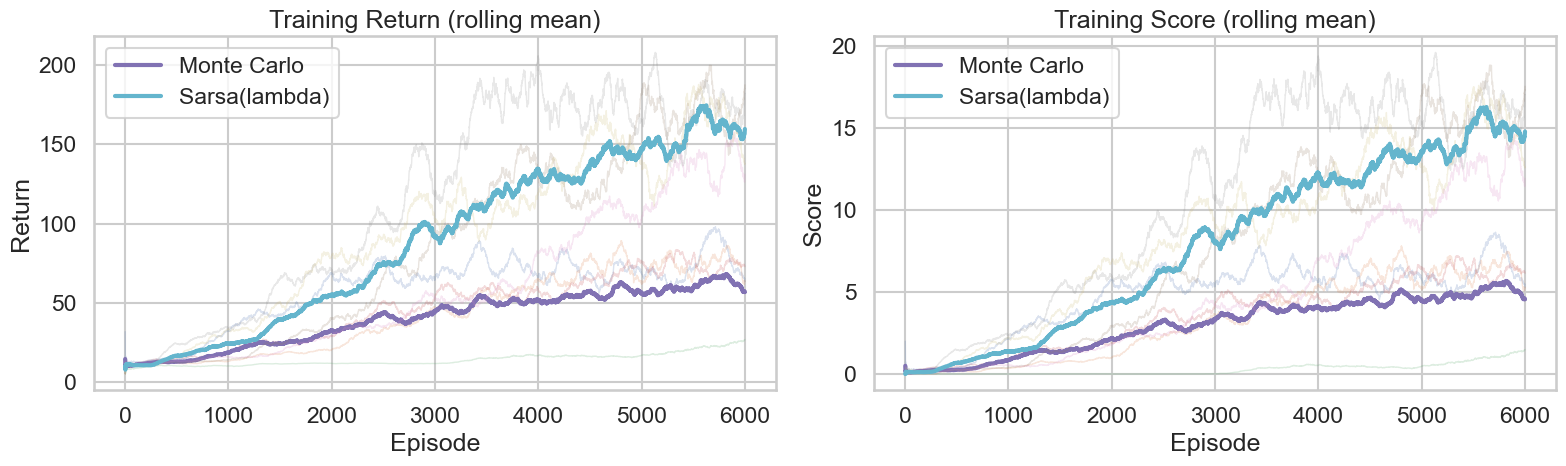

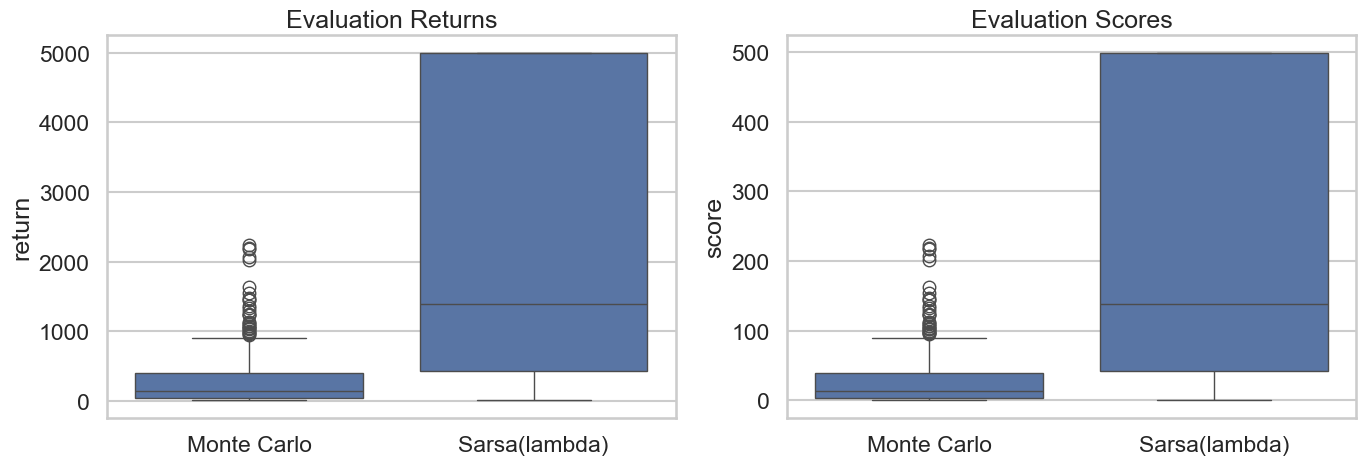

In [ ]:
# Build the shared tabular discretizer and the base environment factory used in the main comparison.
base_discretizer = make_discretizer(**BASE_ENV_CONFIG)
base_env_factory = build_env_factory(env_id=DEFAULT_ENV_ID, **BASE_ENV_CONFIG)

# Define the two agents and all training hyperparameters used in the main experiment.
AGENT_SPECS = {
    "Monte Carlo": {
        "train_fn": train_monte_carlo_control,
        "train_kwargs": {
            "env_factory": base_env_factory,
            "episodes": SETTINGS["train_episodes"],
            "gamma": 0.99,
            "epsilon": 0.08,
            "alpha": 0.05,
            "discretizer": base_discretizer,
            "max_steps": SETTINGS["max_steps"],
        },
    },
    "Sarsa(lambda)": {
        "train_fn": train_sarsa_lambda,
        "train_kwargs": {
            "env_factory": base_env_factory,
            "episodes": SETTINGS["train_episodes"],
            "gamma": 0.99,
            "epsilon": 0.05,
            "alpha": 0.10,
            "lam": 0.90,
            "discretizer": base_discretizer,
            "max_steps": SETTINGS["max_steps"],
            "trace_type": "replacing",
        },
    },
}

# Inspect both environment variants once to compare their action spaces,
# observation spaces, and example observations.
comparison_rows = []
for env_id in [DEFAULT_ENV_ID, SCREEN_ENV_ID]:
    try:
        env = build_env_factory(env_id=env_id, **BASE_ENV_CONFIG)()
        obs, _ = reset_env(env, seed=GLOBAL_SEED)
        comparison_rows.append({"env_id": env_id, "action_space": repr(getattr(env, "action_space", "n/a")), "observation_space": repr(getattr(env, "observation_space", "n/a")), "sample_observation": preview_observation(obs)})
        env.close()
    except Exception as exc:
        # If one environment cannot be initialized, keep the comparison table informative.
        comparison_rows.append({"env_id": env_id, "action_space": "unavailable", "observation_space": "unavailable", "sample_observation": f"Could not initialize environment: {exc}"})

# Display the environment comparison table in the notebook.
environment_comparison = pd.DataFrame(comparison_rows)
display(environment_comparison)

# Train and evaluate each agent under the exact same protocol and seeds.
suite_results = {}
for agent_name, spec in AGENT_SPECS.items():
    suite_results[agent_name] = run_training_suite(agent_name=agent_name, train_fn=spec["train_fn"], train_kwargs=spec["train_kwargs"], seeds=SETTINGS["seeds"], eval_episodes=SETTINGS["eval_episodes"])

# Merge all per-agent training histories into one dataframe for plotting.
learning_history = pd.concat([result["history"] for result in suite_results.values()], ignore_index=True)
# Merge all per-agent evaluation episodes into one dataframe for comparison.
evaluation_results = pd.concat([result["evaluation"] for result in suite_results.values()], ignore_index=True)

# Build a compact summary table of final evaluation performance.
summary_table = evaluation_results.groupby("agent").agg(mean_return=("return", "mean"), std_return=("return", "std"), mean_score=("score", "mean"), std_score=("score", "std"), mean_length=("length", "mean")).reset_index()
# Add the average number of visited tabular states as a rough measure of explored coverage.
summary_table["avg_visited_states"] = summary_table["agent"].map(lambda agent: np.mean([len(q_table) for q_table in suite_results[agent]["q_tables"].values()]))

# Display the summary table sorted by average evaluation score.
display(summary_table.sort_values("mean_score", ascending=False))

# Plot the smoothed training curves for return and score.
plot_learning_curves(learning_history, rolling_window=SETTINGS["rolling_window"])
# Plot the evaluation return and score distributions across agents.
plot_evaluation_distributions(evaluation_results)

### Discussion of the learning curves and evaluation results

The learning curves show that **Sarsa($\lambda$)** learns much faster than **Monte Carlo** and reaches clearly higher training return and training score throughout training. After the early episodes, the gap between the two methods becomes large and remains stable until the end. This suggests that Sarsa($\lambda$) is more sample-efficient in this task.

A natural explanation is that Sarsa($\lambda$) combines **bootstrapping** with **eligibility traces**, which allows reward information to propagate quickly across recently visited state-action pairs. In contrast, Monte Carlo updates only after the end of each episode, so learning is slower and useful feedback spreads less efficiently.

The evaluation boxplots confirm the same conclusion. With greedy evaluation after training, **Sarsa($\lambda$)** strongly outperforms Monte Carlo in both return and score. Its median performance is much higher, and its distribution extends to much larger values, showing that it learns a significantly stronger final policy.

Monte Carlo still learns a non-trivial policy, but its performance remains much lower and more limited. Finally, the evaluation scores are much higher than the smoothed training scores because training is performed with **$\epsilon$-greedy exploration**, while evaluation uses a fully greedy policy (**$\epsilon = 0$**).

## 4. Parameter Sensitivity

The assignment asks for parameter sweeps, so the next experiment studies how the two algorithms react to changes in exploration, step size, and eligibility-trace decay.

,epsilon,alpha,eval_mean_return,eval_mean_score
0,0.020,0.020,14.162,0.525
1,0.020,0.050,16.928,0.617
2,0.020,0.100,66.160,5.562
3,0.050,0.020,29.617,1.945
4,0.050,0.050,52.135,4.192
5,0.050,0.100,96.632,8.520
6,0.100,0.020,50.570,4.015
7,0.100,0.050,541.003,53.110
8,0.100,0.100,118.298,10.867
9,0.200,0.020,54.775,4.367


,alpha,lam,eval_mean_return,eval_mean_score
0,0.050,0.400,12.180,0.193
1,0.050,0.700,16.660,0.723
2,0.050,0.900,28.512,1.820
3,0.050,0.970,23.705,1.248
4,0.100,0.400,35.602,2.545
5,0.100,0.700,52.175,4.117
6,0.100,0.900,99.528,8.822
7,0.100,0.970,232.648,22.312
8,0.200,0.400,92.463,8.055
9,0.200,0.700,1779.192,176.735


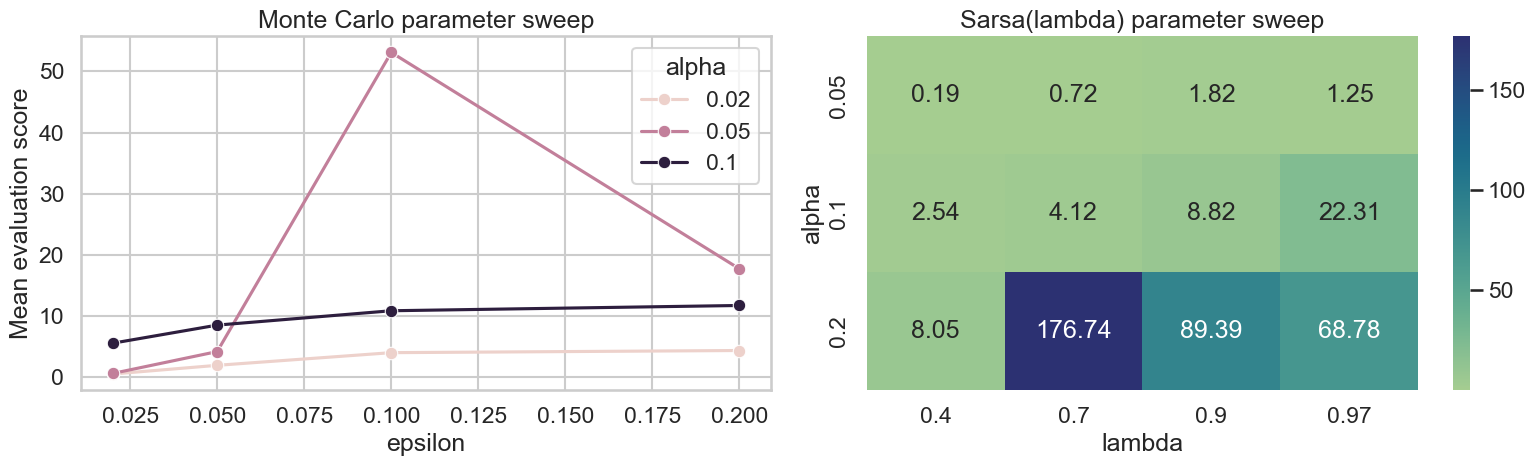

In [ ]:
# Run a compact Monte Carlo hyperparameter sweep to study sensitivity to
# exploration rate (epsilon) and learning rate (alpha).
mc_sweep = parameter_sweep(
    agent_name="Monte Carlo",
    train_fn=train_monte_carlo_control,
    fixed_kwargs={"env_factory": base_env_factory, "episodes": SETTINGS["sweep_episodes"], "gamma": 0.99, "discretizer": base_discretizer, "max_steps": SETTINGS["max_steps"]},
    param_grid={"epsilon": [0.02, 0.05, 0.10, 0.20], "alpha": [0.02, 0.05, 0.10]},
    seeds=SETTINGS["seeds"],
    eval_episodes=SETTINGS["eval_episodes"],
)

# Run a compact Sarsa(lambda) hyperparameter sweep to study sensitivity to
# the step size (alpha) and the trace decay parameter (lambda).
sarsa_sweep = parameter_sweep(
    agent_name="Sarsa(lambda)",
    train_fn=train_sarsa_lambda,
    fixed_kwargs={"env_factory": base_env_factory, "episodes": SETTINGS["sweep_episodes"], "gamma": 0.99, "epsilon": 0.05, "discretizer": base_discretizer, "max_steps": SETTINGS["max_steps"], "trace_type": "replacing"},
    param_grid={"alpha": [0.05, 0.10, 0.20], "lam": [0.40, 0.70, 0.90, 0.97]},
    seeds=SETTINGS["seeds"],
    eval_episodes=SETTINGS["eval_episodes"],
)

# Display the average evaluation metrics for each Monte Carlo parameter pair.
display(mc_sweep.groupby(["epsilon", "alpha"], as_index=False)[["eval_mean_return", "eval_mean_score"]].mean())

# Display the average evaluation metrics for each Sarsa(lambda) parameter pair.
display(sarsa_sweep.groupby(["alpha", "lam"], as_index=False)[["eval_mean_return", "eval_mean_score"]].mean())

# Visualize the sweep results to compare parameter sensitivity across the two agents.
plot_parameter_sweeps(mc_sweep, sarsa_sweep)

### Discussion of the parameter sweeps

The parameter sweeps show that both agents are sensitive to hyperparameter choices, but **Sarsa($\lambda$)** is much more capable of reaching high performance when well tuned. For **Monte Carlo**, the results remain relatively modest overall. The best region appears around **$\alpha = 0.05$** and **$\epsilon = 0.10$**, where the mean evaluation score rises sharply, while too little exploration or too small a step size leads to much weaker performance. When **$\alpha = 0.10$**, the scores are more stable but lower, suggesting a more conservative but less effective behavior.

For **Sarsa($\lambda$)**, the sweep reveals a much stronger dependence on both **$\alpha$** and **$\lambda$**. Small step sizes perform poorly, while larger values of **$\alpha$** give a major improvement. The best result is obtained around **$\alpha = 0.20$** and **$\lambda = 0.70$**, with very high evaluation scores. This indicates that eligibility traces are highly beneficial, but only when combined with a sufficiently aggressive learning rate. Very small **$\lambda$** values underuse the trace mechanism, while very large values are not always optimal. Overall, the figure shows that **Sarsa($\lambda$)** has much higher performance potential than Monte Carlo, but also requires more careful tuning.

## 5. Value-Function And Policy Inspection

A representative seed is enough to visualize where each agent assigns high value and how the resulting greedy policy separates `idle` from `flap` decisions in the discretized state space.

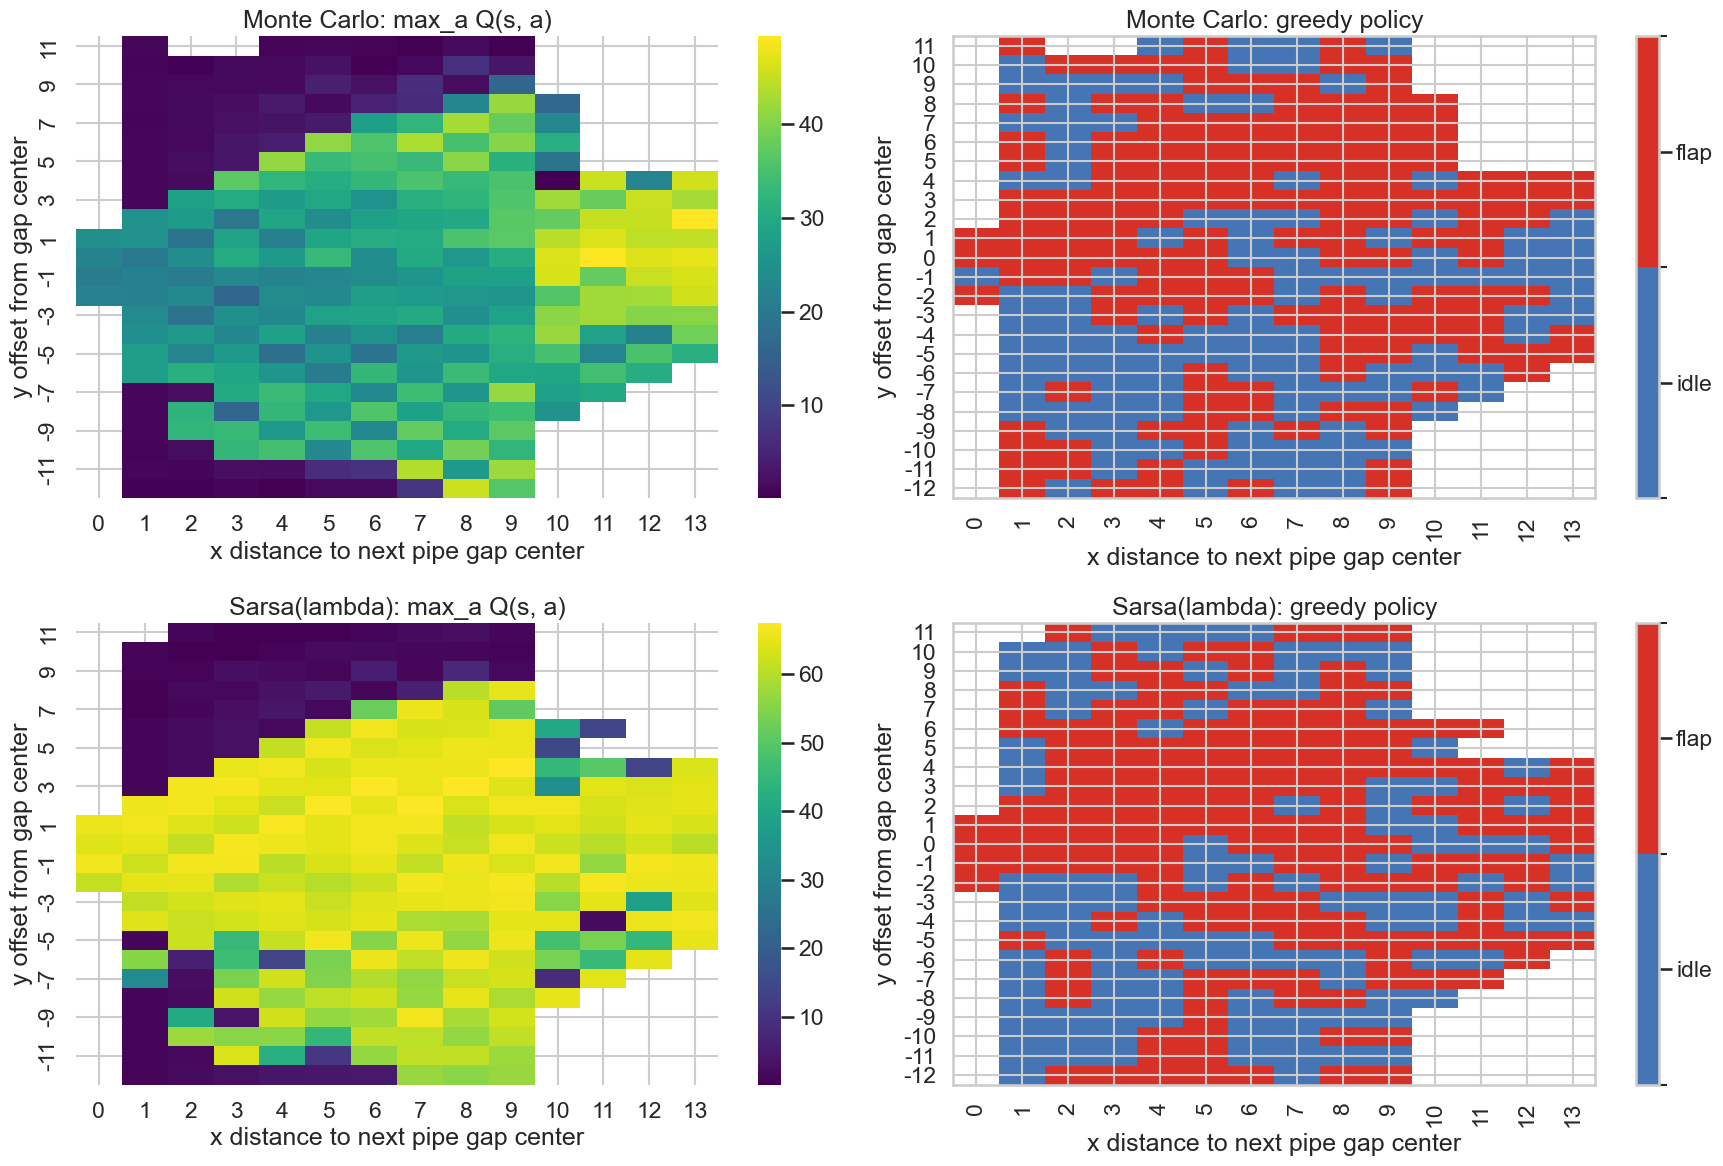

In [8]:
# One representative seed is enough to inspect the learned value structure and greedy action map.
reference_seed = SETTINGS["seeds"][0]
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plot_value_heatmap(suite_results["Monte Carlo"]["q_tables"][reference_seed], "Monte Carlo: max_a Q(s, a)", ax=axes[0, 0])
plot_policy_heatmap(suite_results["Monte Carlo"]["q_tables"][reference_seed], "Monte Carlo: greedy policy", ax=axes[0, 1])
plot_value_heatmap(suite_results["Sarsa(lambda)"]["q_tables"][reference_seed], "Sarsa(lambda): max_a Q(s, a)", ax=axes[1, 0])
plot_policy_heatmap(suite_results["Sarsa(lambda)"]["q_tables"][reference_seed], "Sarsa(lambda): greedy policy", ax=axes[1, 1])
plt.tight_layout()
plt.show()


### Discussion of the value-function and policy heatmaps

The value heatmaps show that both agents have learned a meaningful structure over the discretized state space. In both cases, the estimated value is generally lower when the bird is far from the safe region around the pipe gap, and higher in states that are closer to positions from which survival is more likely. However, **Sarsa($\lambda$)** produces overall larger and more uniformly high values than **Monte Carlo**, which is consistent with its stronger empirical performance in the training and evaluation plots.

The greedy policy maps are also informative. Both agents learn a non-trivial switching pattern between **idle** and **flap**, rather than collapsing to a single action everywhere. This means they capture the basic control logic of the game: flap in some regions to gain height, and stay idle in others to avoid overshooting. Still, the **Sarsa($\lambda$)** policy appears more coherent and structured, with larger contiguous regions of the same action, while the Monte Carlo policy looks noisier and more fragmented. This suggests that Sarsa($\lambda$) learns a cleaner decision boundary over the state space.

Taken together, these plots support the quantitative results. Monte Carlo does learn useful value estimates and a workable policy, but its representation remains less sharp and less consistent. **Sarsa($\lambda$)** not only achieves higher returns and scores, but also learns a more stable value landscape and a more organized greedy policy, which likely explains its better control performance.

## 6. Generalization Across Level Configurations

The next experiment answers the transfer question from the assignment by evaluating the learned Q-tables directly on unseen level geometries, without any additional fine-tuning.

,agent,config,mean_return,mean_score,mean_length
0,Monte Carlo,narrow_gap,40.197,2.737,40.197
1,Monte Carlo,taller_level,163.590,15.350,163.590
2,Monte Carlo,train_config,328.743,31.827,328.743
3,Monte Carlo,wide_gap,334.997,32.357,334.997
4,Monte Carlo,wider_level,116.590,8.920,116.590
5,Sarsa(lambda),narrow_gap,25.690,1.280,25.690
6,Sarsa(lambda),taller_level,286.637,27.503,286.637
7,Sarsa(lambda),train_config,2629.827,261.940,2629.827
8,Sarsa(lambda),wide_gap,3708.337,369.707,3708.337
9,Sarsa(lambda),wider_level,642.863,52.773,642.863


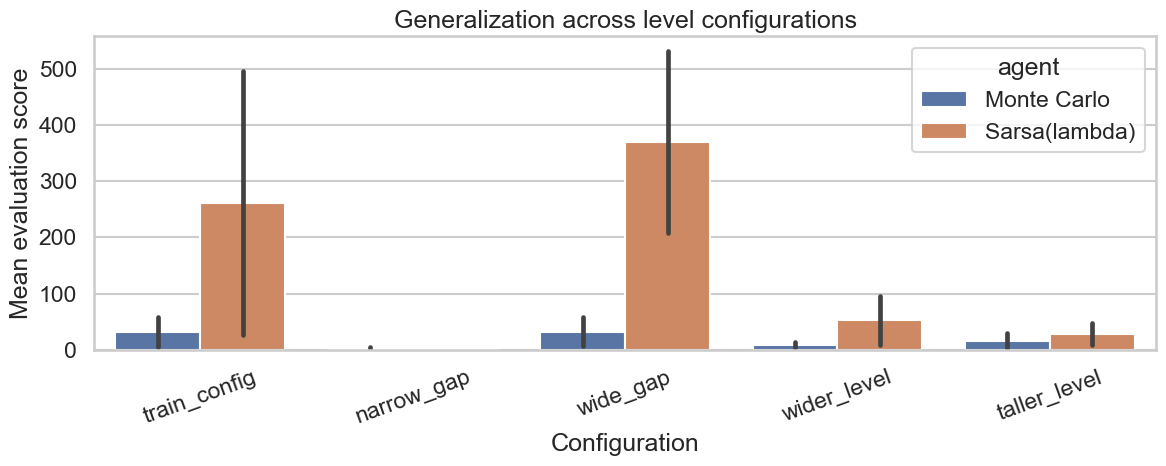

In [9]:
# Reuse the trained Q-tables directly on unseen geometries to measure zero-shot generalization.
generalization_configs = {
    "train_config": {"height": 15, "width": 20, "pipe_gap": 4},
    "narrow_gap": {"height": 15, "width": 20, "pipe_gap": 3},
    "wide_gap": {"height": 15, "width": 20, "pipe_gap": 5},
    "wider_level": {"height": 15, "width": 24, "pipe_gap": 4},
    "taller_level": {"height": 18, "width": 20, "pipe_gap": 4},
}

generalization_rows = []
for agent_name, result in suite_results.items():
    for seed, q_table in result["q_tables"].items():
        for config_name, env_config in generalization_configs.items():
            eval_df = evaluate_policy(env_factory=build_env_factory(env_id=DEFAULT_ENV_ID, **env_config), q_table=q_table, episodes=SETTINGS["transfer_eval_episodes"], discretizer=make_discretizer(**env_config), seed=20_000 + seed, epsilon=0.0, max_steps=SETTINGS["max_steps"])
            generalization_rows.append({"agent": agent_name, "seed": seed, "config": config_name, "mean_return": eval_df["return"].mean(), "mean_score": eval_df["score"].mean(), "mean_length": eval_df["length"].mean()})

generalization_df = pd.DataFrame(generalization_rows)
display(generalization_df.groupby(["agent", "config"], as_index=False)[["mean_return", "mean_score", "mean_length"]].mean())
plt.figure(figsize=(12, 5))
sns.barplot(data=generalization_df, x="config", y="mean_score", hue="agent", ci="sd")
plt.title("Generalization across level configurations")
plt.ylabel("Mean evaluation score")
plt.xlabel("Configuration")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Discussion of the generalization results

The generalization experiment shows that both agents are strongly affected by changes in the level configuration. Performance is highest on the **training configuration** and on the **wide\_gap** setting, especially for **Sarsa($\lambda$)**, which keeps a large advantage over Monte Carlo in these easier or more permissive environments. This suggests that part of the learned policy transfers when the new layout remains close to the original dynamics or becomes slightly more forgiving.

In contrast, performance drops sharply on configurations such as **narrow\_gap**, where both agents nearly fail completely. This indicates that the learned tabular policies are not robust to major changes in the geometry of the task. Since the state representation and value estimates are tied to a specific discretized environment, even moderate changes in the pipe layout can invalidate the learned action preferences.

The results on **wider\_level** and **taller\_level** are intermediate: transfer is possible, but much weaker than on the base configuration. Overall, **Sarsa($\lambda$)** generalizes better than Monte Carlo across all tested settings, but neither agent shows strong robustness. This confirms that the learned policies are effective mainly near the training regime, and that generalization remains limited in this tabular setup.

# Final conclusions

This notebook compared **constant-$\alpha$ first-visit Monte Carlo control** and **Sarsa($\lambda$) with replacing eligibility traces** on the **Text Flappy Bird** environment.

Overall, the results are clear: **Sarsa($\lambda$) is the stronger method in this setting**. It learns faster, reaches much higher training returns and scores, and produces substantially better greedy evaluation performance than Monte Carlo. The learning curves, boxplots, parameter sweeps, and value/policy visualizations all support the same conclusion.

Monte Carlo still learns a meaningful policy and captures useful structure in the state space, but it remains slower and less effective. Its updates rely on complete episodes, which makes reward propagation less efficient. In contrast, Sarsa($\lambda$) benefits from **bootstrapping** and **eligibility traces**, allowing it to adapt more quickly and learn a more coherent control policy.

The parameter sweeps also show an important trade-off. **Sarsa($\lambda$) has much higher performance potential, but it is also more sensitive to hyperparameters**, especially $\alpha$ and $\lambda$. Monte Carlo is simpler and somewhat more predictable, but its best performance remains clearly below that of a well-tuned Sarsa($\lambda$) agent.

The transfer experiments highlight an important limitation of this tabular approach: **generalization across level configurations is weak**. Both agents perform best near the training configuration and can fail badly when the geometry changes significantly, especially for narrow pipe gaps. This shows that the learned policies are strongly tied to the discretized state representation and to the training environment.

Finally, the comparison between `TextFlappyBird-v0` and `TextFlappyBird-screen-v0` confirms why the compact-state version is appropriate for this assignment. The tabular agents can be applied directly to the compact environment because the observation space is low-dimensional and structured. In contrast, the screen-based environment is much less suitable for a tabular method, since it would require either an impractically large table or a function-approximation approach such as deep reinforcement learning.

In summary, the experiments show that:

- **Sarsa($\lambda$) outperforms Monte Carlo** in learning speed and final performance
- **Monte Carlo remains simpler but clearly weaker**
- **hyperparameter tuning matters**, especially for Sarsa($\lambda$)
- **generalization is limited** in this tabular setting
- the compact-state TFB environment is a good fit for tabular RL, whereas the screen-based or original Flappy Bird setting would require more advanced methods

These results make Sarsa($\lambda$) the preferred choice for this assignment, while also illustrating the practical limits of tabular reinforcement learning on environment variations.